# **🛍 Scenario: Fashion Product Image Classifier**
You are working as an AI Engineer for an e-commerce company.

The company wants to automatically classify clothing products from images into categories such as:
- T-shirt
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot
The dataset contains 28×28 grayscale images of fashion items.

Your goal is to build a Convolutional Neural Network (CNN) that can classify these fashion products correctly.

###**Task 1 — Dataset Exploration**
Load the Fashion-MNIST dataset and perform basic inspection.
Students must:
- Load dataset using TensorFlow/Keras
- Print:

    - Number of training images

    - Number of testing images
- Display 10 random images with their labels
Goal:
Understand the dataset visually.
##**Task 2 — Data Preprocessing**
Prepare the dataset for CNN training.
Students must:
- Normalize pixel values (0–255 → 0–1)
- Reshape images to CNN format

Expected shape:

    (28, 28, 1)
Also convert labels to one-hot encoding.

##**Task 3 — Visualize Class Distribution**
Students must:
- Count number of images in each class
- Plot bar chart of class distribution
Goal:

Check whether the dataset is balanced.
##**Task 5 — Model Compilation**
Students must compile the model using:
- Optimizer → Adam
- Loss → categorical crossentropy
- Metrics → accuracy
Goal:

Understand how models are configured before training.
##**Task 6 — Train the Model**
Train the CNN with:
- Epochs = 10
- Batch size = 64
- Validation split = 20%

Students must:
- Plot training accuracy vs validation accuracy
- Plot training loss vs validation loss
Goal:

Observe model learning behaviour.


##**Task 7 — Model Evaluation**
Evaluate model performance on test dataset.
Students must print:
- Test accuracy
- Test loss

Then display 5 test images with predictions.

Goal:

Understand how models generalize to unseen data.

##**Task 8 — Confusion Matrix Analysis**
Students must:
- Generate confusion matrix
- Visualize using heatmap

Goal:

Understand which classes are misclassified.

Example challenge:

    Shirt vs T-shirt
    Sneaker vs Ankle Boot
These are commonly confused.


##**Task 9 — Improve the CNN Architecture**
Students must modify the architecture by:
- Adding Dropout layer
- Increasing filters
- Adding another convolution layer

Example:

    Conv → Conv → Pool → Conv → Pool

Then compare:

    Model 1 accuracy vs Model 2 accuracy
Goal:

Understand model improvement strategies.


##**Task 10 — Misclassification Analysis**
Students must:

- Identify 5 wrongly predicted images
- Display:
    - Actual label
    - Predicted label

Then explain:

    Why might the model confuse these classes?
    
Goal:
Develop model debugging skills.


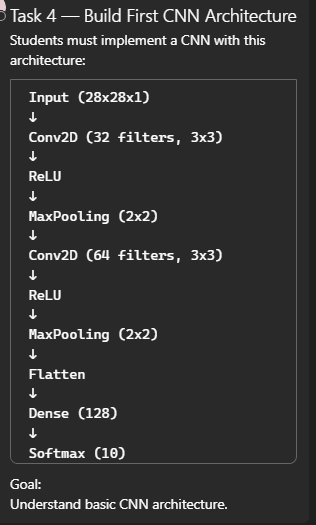

Training images: 60000
Testing images: 10000


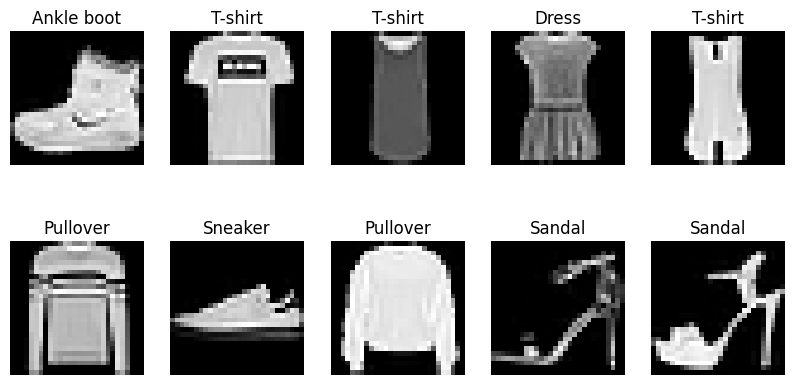

In [19]:
#  1: Load dataset, inspect size, show 10 images

from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np


(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images:", x_train.shape[0])
print("Testing images:", x_test.shape[0])


class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']


plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [21]:
#  2: Normalize images, reshape for CNN, one-hot encode labels

from keras.utils import to_categorical


x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# reshape for CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# one-hot encode labels
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

print("x_train shape:",x_train.shape)
print("y_train shape:",y_train.shape)

x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)


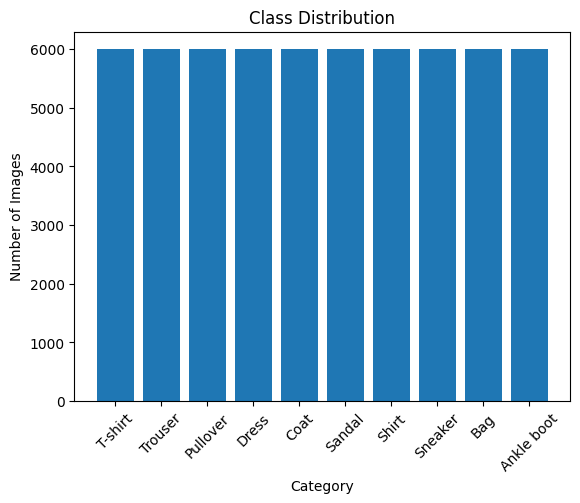

In [22]:
#  3: Count images per class and plot distribution

labels = np.argmax(y_train, axis=1)

class_counts = np.bincount(labels)

class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.bar(class_names, class_counts)
plt.xticks(rotation=45)

plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Images")

plt.show()

In [23]:
# 4: Build CNN model

from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128,activation='relu'),

    Dense(10,activation='softmax')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# **5.Model Compilation**

In [24]:
# 5: Compile CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##**Train the Model**

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7375 - loss: 0.7445 - val_accuracy: 0.8587 - val_loss: 0.3935
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8717 - loss: 0.3603 - val_accuracy: 0.8848 - val_loss: 0.3212
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8895 - loss: 0.3057 - val_accuracy: 0.8921 - val_loss: 0.2991
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9035 - loss: 0.2660 - val_accuracy: 0.8878 - val_loss: 0.2936
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9118 - loss: 0.2409 - val_accuracy: 0.9053 - val_loss: 0.2629
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9219 - loss: 0.2096 - val_accuracy: 0.9038 - val_loss: 0.2702
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9277 - loss: 0.1911 - val_accuracy: 0.9149 - val_loss: 0.2361
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9353 - loss: 0.1737 - val_accuracy: 0.

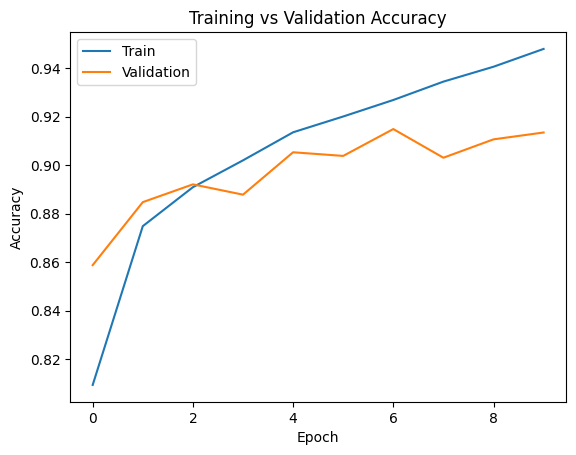

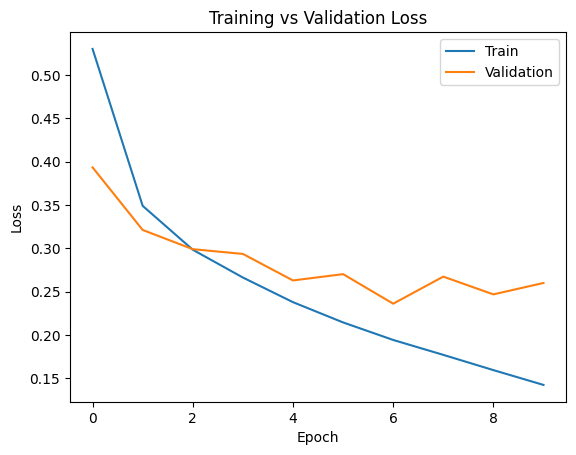

In [25]:
#  6: Train CNN and plot training behavior

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9101 - loss: 0.2753
Test Accuracy: 0.9092000126838684
Test Loss: 0.2733091413974762
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


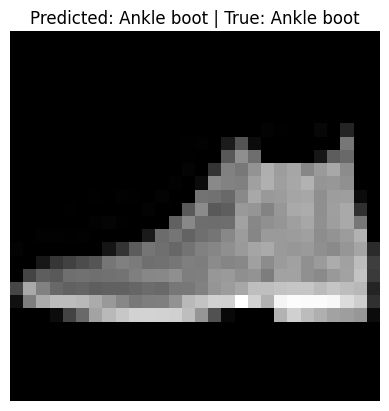

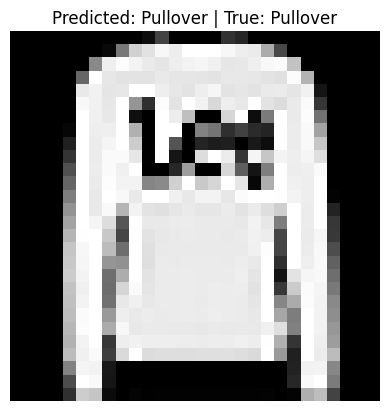

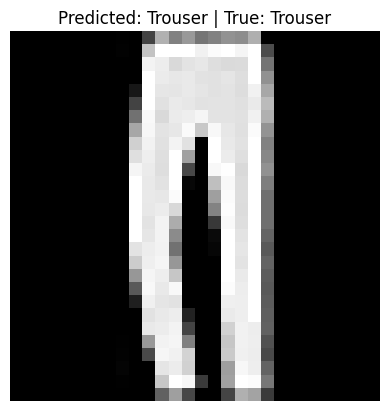

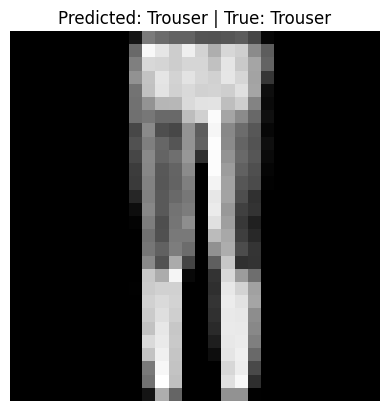

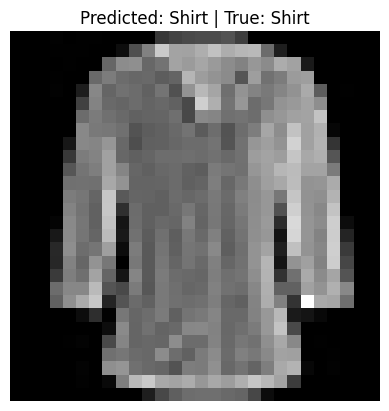

In [26]:
# 7: Evaluate model on test data and show predictions


test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)


class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']


for i in range(5):

    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    plt.title(
        "Predicted: " + class_names[predicted_classes[i]] +
        " | True: " + class_names[true_classes[i]]
    )

    plt.axis('off')
    plt.show()

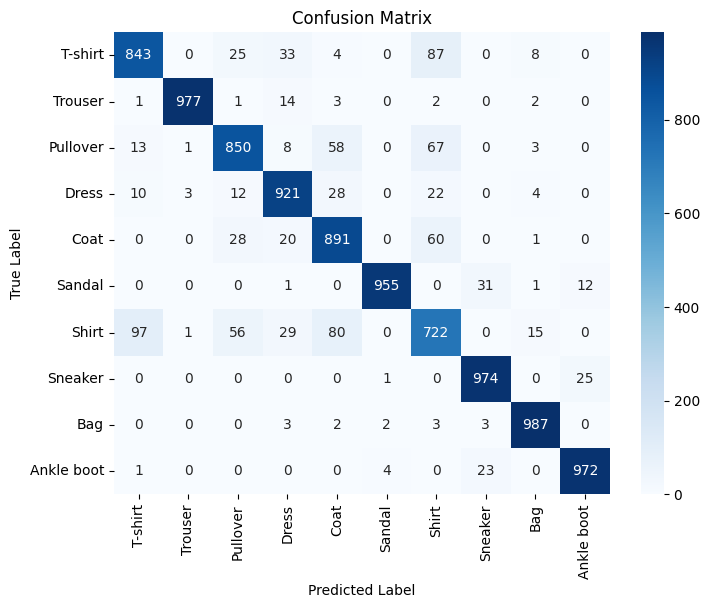

In [27]:
# 8: Generate confusion matrix and visualize heatmap

from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(true_classes, predicted_classes)


class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [28]:
# 9: Build improved CNN with more layers and dropout

from keras.layers import Dropout


model2 = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(10,activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

print("Model 1 Test Accuracy:", test_accuracy)
print("Model 2 Test Accuracy:", test_accuracy2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6773 - loss: 0.8954 - val_accuracy: 0.8602 - val_loss: 0.3719
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8532 - loss: 0.4148 - val_accuracy: 0.8849 - val_loss: 0.3095
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8759 - loss: 0.3478 - val_accuracy: 0.8997 - val_loss: 0.2760
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8924 - loss: 0.3014 - val_accuracy: 0.9072 - val_loss: 0.2527
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9015 - loss: 0.2750 - val_accuracy: 0.9133 - val_loss: 0.2390
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9132 - loss: 0.2485 - val_accuracy: 0.9142 - val_loss: 0.2365
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9151 - loss: 0.2332 - val_accuracy: 0.9153 - val_loss: 0.2355
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9220 - loss: 0.2204 - val_accuracy: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


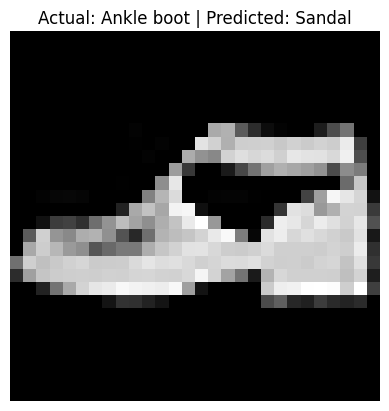

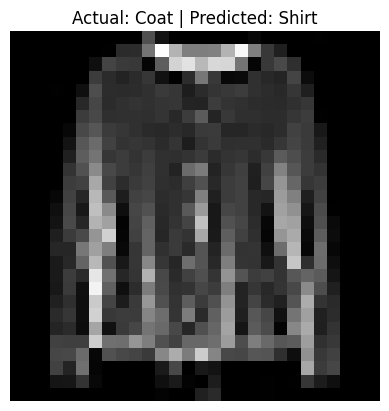

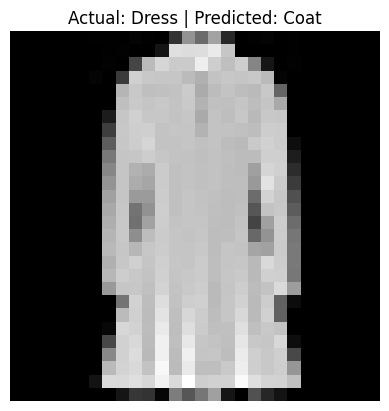

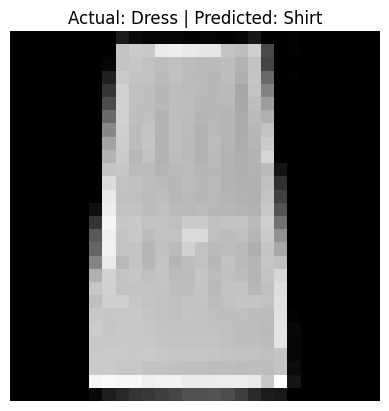

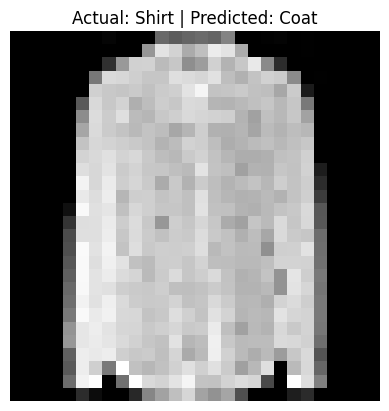

In [29]:
# 10: Find wrongly predicted images and display them


predictions2 = model2.predict(x_test)

predicted_classes2 = np.argmax(predictions2, axis=1)
true_classes = np.argmax(y_test, axis=1)


class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']


wrong = np.where(predicted_classes2 != true_classes)[0]


for i in range(5):

    index = wrong[i]

    plt.imshow(x_test[index].reshape(28,28), cmap='gray')

    plt.title(
        "Actual: " + class_names[true_classes[index]] +
        " | Predicted: " + class_names[predicted_classes2[index]]
    )

    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step


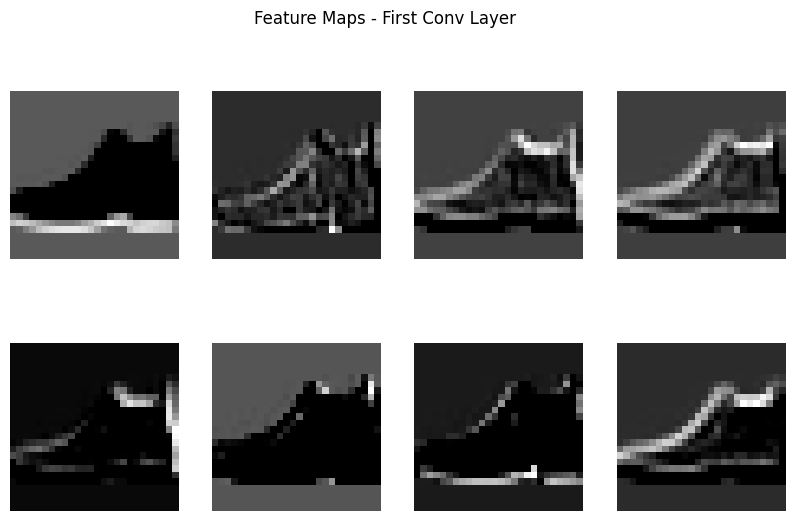

In [31]:
# 11: Visualize CNN feature maps for one image

from keras.models import Model

img = x_test[0].reshape(1,28,28,1)


_ = model2.predict(img)


layer_outputs = [layer.output for layer in model2.layers if isinstance(layer, Conv2D)]


feature_model = Model(inputs=model2.inputs, outputs=layer_outputs)


feature_maps = feature_model.predict(img)


first_layer_maps = feature_maps[0]

plt.figure(figsize=(10,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(first_layer_maps[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle("Feature Maps - First Conv Layer")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


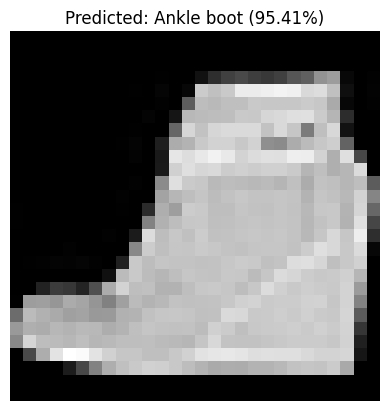

In [32]:
#  12: Take a random test image and predict its class


class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

index = np.random.randint(0, x_test.shape[0])

img = x_test[index]


prediction = model2.predict(img.reshape(1,28,28,1))

predicted_class = np.argmax(prediction)
probability = np.max(prediction)


plt.imshow(img.reshape(28,28), cmap='gray')

plt.title(
    "Predicted: " + class_names[predicted_class] +
    " (" + str(round(probability*100,2)) + "%)"
)

plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


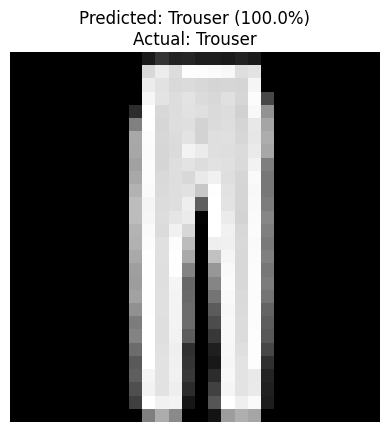

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


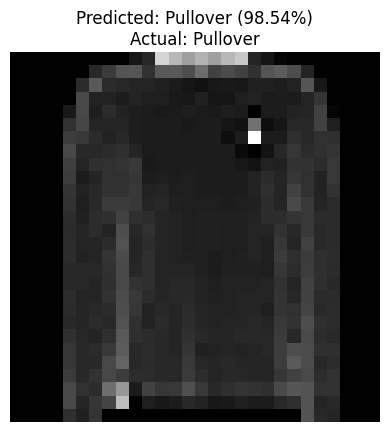

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


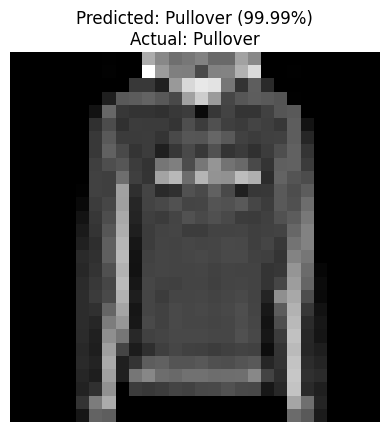

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


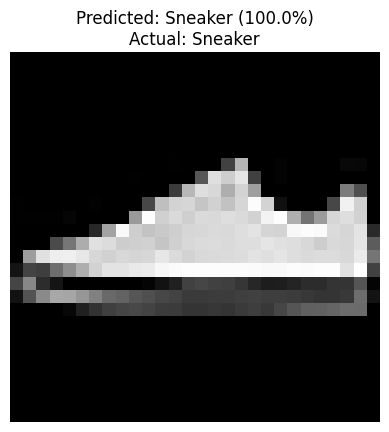

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


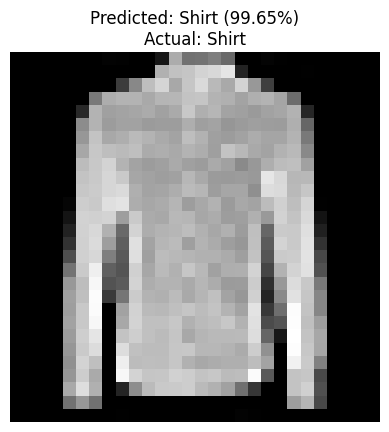

In [33]:
# Test model on few random samples


class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

indices = np.random.choice(x_test.shape[0], 5)

for i in indices:

    img = x_test[i]


    prediction = model2.predict(img.reshape(1,28,28,1))

    predicted_class = np.argmax(prediction)
    probability = np.max(prediction)

    true_class = np.argmax(y_test[i])

    plt.imshow(img.reshape(28,28), cmap='gray')

    plt.title(
        "Predicted: " + class_names[predicted_class] +
        " (" + str(round(probability*100,2)) + "%)\n"
        "Actual: " + class_names[true_class]
    )

    plt.axis('off')
    plt.show()